In [ ]:
# 行动步骤三：训练 LD-Net 降噪模型{V2 - 带自动保存}

# 本脚本用于训练在 models/LD_Net.py 中定义的 1D-UNet 降噪模型。
#
# **训练前的重要步骤：**
# 1. 设置 DATASET_NAME：选择 "SIAT" 或 "UCI"在单元格4
# 2. 手动修改 utils/common_params.py：
#    - SIAT: C=9, raw_fs=1920, tar_fs=1000, num_classes=5
#    - UCI:  C=4, raw_fs=1000, tar_fs=1000, num_classes=3

# 模型 (LD_Net) 会自动从 common_params.py 中读取通道数 C。

In [1]:
# 单元格 2：导入依赖与初始化
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim  # 我们将从这里调用 AdamW
from torch.utils.data import DataLoader
from tqdm.auto import tqdm  # 推荐使用 tqdm.auto
import matplotlib.pyplot as plt
import time
from thop import profile
import json

# --- 关键：确保项目根目录在路径中 ---
# 假设此脚本在 'LD_train Test' 文件夹, 'trainTest' 文件夹的上一级是 'Code2' 根目录
path = os.path.join(os.getcwd(), '..', '..')  # '..' -> trainTest, '..' -> Code2 (根目录)
sys.path.append(path)

# --- 导入您的项目文件 ---
from utils.common_utils import printlog, set_seed, make_dir
from utils.common_params import *  # 确保这个文件已根据 DATASET_NAME 手动修改!
from models.LD_Net import LD_Net  # 导入行动二中创建的 LD-Net (带 Dropout 的版本)
from trainTest.datasets.denoise_dataset_utils import DenoiseDataset  # 导入您的 Dataset
from trainTest.metrics.denoising_metrics import calculate_rmse, calculate_snr  # 导入您的 Metrics
from trainTest.early_stopping.early_stopping import EarlyStopping  # 复用已有的 EarlyStopping

# 设置随机种子
set_seed(seed=42)  # 使用一个固定的种子
print("所有依赖导入成功。")


所有依赖导入成功。


In [2]:
# 单元格 3：参数配置 (修正版)

# === 1. 数据集选择 ===
# ！！！关键！！！: 运行SIAT时设为 "SIAT", 运行UCI时设为 "UCI"
DATASET_NAME = "SIAT"
# DATASET_NAME = "UCI"

# === 2. 超参数 (防过拟合) ===
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
EPOCHS = 200
PATIENCE = 15 # Early Stopping 的耐心值 (15-20 均可)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 💡 关键防过拟合策略：L2 正则化 (权重衰减)
WEIGHT_DECAY = 1e-4

# === 3. 数据路径配置 (已更新为 步骤一 的新路径) ===
# (假设 'preProcessing' 文件夹在项目根目录)
base_data_path = os.path.join(path, "preProcessing") # path 已在单元格2中定义为根目录

siat_data_path = os.path.join(base_data_path, "SIAT_LLMD_trainData", "Denoising_TrainSet_XY")
uci_data_path = os.path.join(base_data_path, "UCI_trainData", "Denoising_TrainSet_XY")

if DATASET_NAME == "SIAT":
    data_dir = siat_data_path
    subjects_train = ['Sub01', 'Sub02', 'Sub03', 'Sub04', 'Sub05', 'Sub31', 'Sub32', 'Sub33']
    subjects_val = ['Sub34']
    subjects_test = ['Sub35']
    # 确保 common_params.py 中的 C=9
    n_channels_check = 9
else: # 默认为 "UCI"
    data_dir = uci_data_path
    subjects_train = ['1N', '2N', '3N', '4N', '5N', '7A', '8A', '9A']
    subjects_val = ['10A']
    subjects_test = ['11A']
    # 确保 common_params.py 中的 C=4
    n_channels_check = 4

# === 4. 检查参数一致性 ===
print(f"--- 训练配置: {DATASET_NAME} ---")
print(f"设备: {DEVICE}")
print(f"防过拟合 (AdamW) Weight Decay: {WEIGHT_DECAY}")
print(f"数据源: {data_dir}")
if C != n_channels_check:
    print(f"⚠️ 警告: common_params.py 中的 C={C} 与所选数据集 {DATASET_NAME} (应为 {n_channels_check}) 不匹配!")
else:
    print("✅ C 参数检查通过。")

# === 5. 模型保存路径 (已更新为您期望的路径) ===
# os.getcwd() 现在是 E:\...\LD_train Test
save_dir = os.path.join(os.getcwd(), 'checkpoints', f'LD_Net_{DATASET_NAME}')
make_dir(save_dir)
best_model_path = os.path.join(save_dir, 'ld_net_best_model.pth')
results_json_path = os.path.join(save_dir, 'test_results.json')
figure_save_path = os.path.join(save_dir, 'denoising_comparison.png')

print(f"模型将保存到: {best_model_path}")
print(f"结果将保存到: {results_json_path}")
print(f"图表将保存到: {figure_save_path}")

--- 训练配置: SIAT ---
设备: cuda
防过拟合 (AdamW) Weight Decay: 0.0001
数据源: E:\基于肌电图的下肢运动模式识别\Code2\trainTest\LD_train Test\..\..\preProcessing\SIAT_LLMD_trainData\Denoising_TrainSet_XY
✅ C 参数检查通过。
模型将保存到: E:\基于肌电图的下肢运动模式识别\Code2\trainTest\LD_train Test\checkpoints\LD_Net_SIAT\ld_net_best_model.pth
结果将保存到: E:\基于肌电图的下肢运动模式识别\Code2\trainTest\LD_train Test\checkpoints\LD_Net_SIAT\test_results.json
图表将保存到: E:\基于肌电图的下肢运动模式识别\Code2\trainTest\LD_train Test\checkpoints\LD_Net_SIAT\denoising_comparison.png


In [3]:
# 单元格 4：加载数据集
print("--- 加载数据集 ---")

try:
    train_dataset = DenoiseDataset(data_dir=data_dir, subjects_list=subjects_train, is_train=True)
    val_dataset = DenoiseDataset(data_dir=data_dir, subjects_list=subjects_val, is_train=False)
    test_dataset = DenoiseDataset(data_dir=data_dir, subjects_list=subjects_test, is_train=False)
except TypeError:
    # 如果您的 DenoiseDataset 不支持 is_train, 回退到 V1 版本
    print("DenoiseDataset 不支持 'is_train' 参数，已回退。")
    train_dataset = DenoiseDataset(data_dir=data_dir, subjects_list=subjects_train)
    val_dataset = DenoiseDataset(data_dir=data_dir, subjects_list=subjects_val)
    test_dataset = DenoiseDataset(data_dir=data_dir, subjects_list=subjects_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")
printlog("✅ 数据加载完毕。", time=True)

--- 加载数据集 ---
--- 激活训练数据增强 (V3 - Noise, Scale, Jitter, Clamp) ---
--- 正在加载 8 个受试者的数据 ---
成功加载: Sub01_XY_TrainData.npz
成功加载: Sub02_XY_TrainData.npz
成功加载: Sub03_XY_TrainData.npz
成功加载: Sub04_XY_TrainData.npz
成功加载: Sub05_XY_TrainData.npz
成功加载: Sub31_XY_TrainData.npz
成功加载: Sub32_XY_TrainData.npz
成功加载: Sub33_XY_TrainData.npz
总样本数: 4865
--- 正在加载 1 个受试者的数据 ---
成功加载: Sub34_XY_TrainData.npz
总样本数: 498
--- 正在加载 1 个受试者的数据 ---
成功加载: Sub35_XY_TrainData.npz
总样本数: 719
Train samples: 4865, Val samples: 498, Test samples: 719

============================================================2026-02-05 19:33:13
✅ 数据加载完毕。...



In [4]:
# 单元格 5：定义模型、损失函数、优化器

# 1. 定义模型 (V2.2-dual_output)
model = LD_Net().to(DEVICE)

print("损失函数在 单元格 6 中定义（复合损失：clean L1 + 噪声头直监督 + 方差 + DC + alpha护栏）")

# --- 💡 关键改动点 B： γ (gain) 不做 weight decay ---
decay, no_decay = [], []
for name, p in model.named_parameters():
    if name.endswith('gain'):  # gamma 参数
        no_decay.append(p)
        print(f"  > (优化器) 'gain' 参数已设置为 no_decay。")
    else:
        decay.append(p)

optimizer = optim.AdamW(
    [{'params': decay, 'weight_decay': 1e-4},  # 保持 1e-4
     {'params': no_decay, 'weight_decay': 0.0}],  # gain 不衰减
    lr=LEARNING_RATE
)
print(f"优化器: AdamW (lr={LEARNING_RATE}, weight_decay=1e-4, 'gain' 除外)")
# --- 修正结束 ---

# 3. 定义调度器
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.1, patience=5
)
print("调度器: ReduceLROnPlateau (patience=5, factor=0.1)")

# 4. 定义 Early Stopping
early_stopping = EarlyStopping(patience=PATIENCE, verbose=True, path=best_model_path)

LD-Net (V2.4-C48-D0.2) 初始化完成。
  输入/输出通道: 9
  Dropout 概率: 0.2
  基础通道数 (base_c): 48
损失函数在 单元格 6 中定义（复合损失：clean L1 + 噪声头直监督 + 方差 + DC + alpha护栏）
  > (优化器) 'gain' 参数已设置为 no_decay。
优化器: AdamW (lr=0.001, weight_decay=1e-4, 'gain' 除外)
调度器: ReduceLROnPlateau (patience=5, factor=0.1)


In [5]:
# 单元格 6：训练与验证 (安静版 + 💡 关键修正 C：强化 loss_head)

import torch.nn.functional as F

history = {'train_loss': [], 'val_loss': [], 'lr': []}
printlog(f"--- 开始训练 {DATASET_NAME} (clean 1.0 + head 1.0 + ...) ---", time=True)
start_train_time = time.time()

eps = 1e-9

for epoch in range(EPOCHS):
    # ------------------------ 训练 ------------------------
    model.train()
    train_loss_epoch = 0.0

    for noisy_X, clean_Y in train_loader:
        x_noisy = noisy_X.to(DEVICE)
        y_true = clean_Y.to(DEVICE)

        optimizer.zero_grad()

        clean_pred, raw_noise = model(x_noisy)
        n_target = x_noisy - y_true

        # --- 💡 关键改动点 C：新复合损失 (loss_head 权重提升) ---

        loss_clean = F.l1_loss(clean_pred, y_true)

        n_target_zm = n_target - n_target.mean(dim=2, keepdim=True)
        loss_head = F.l1_loss(raw_noise, n_target_zm)

        std_p = raw_noise.std(dim=2, keepdim=True) + eps
        std_t = n_target_zm.std(dim=2, keepdim=True) + eps
        loss_var = F.l1_loss(std_p, std_t)

        loss_dc = raw_noise.mean(dim=2).abs().mean()

        num = (clean_pred * y_true).sum(dim=(1, 2), keepdim=True)
        den = (clean_pred.pow(2).sum(dim=(1, 2), keepdim=True) + eps)
        alpha = num / den
        loss_alpha = (alpha - 1.0).abs().mean()

        # 6) 总损失 (loss_head 权重从 0.5 提升到 1.0)
        loss = (1.0 * loss_clean +
                1.0 * loss_head +  # <-- 权重提升
                0.2 * loss_var +
                0.05 * loss_dc +
                0.02 * loss_alpha)
        # --- 损失结束 ---

        loss.backward()
        optimizer.step()

        train_loss_epoch += loss.item()

    train_loss = train_loss_epoch / len(train_loader)
    history['train_loss'].append(train_loss)
    current_lr = optimizer.param_groups[0]['lr']
    history['lr'].append(current_lr)

    # ------------------------ 验证 ------------------------
    model.eval()
    val_loss_epoch = 0.0
    with torch.no_grad():
        for noisy_X, clean_Y in val_loader:
            x_noisy = noisy_X.to(DEVICE)
            y_true = clean_Y.to(DEVICE)

            clean_pred, raw_noise = model(x_noisy)
            n_target = x_noisy - y_true

            # (在验证时也使用新权重)
            loss_clean = F.l1_loss(clean_pred, y_true)
            n_target_zm = n_target - n_target.mean(dim=2, keepdim=True)
            loss_head = F.l1_loss(raw_noise, n_target_zm)
            std_p = raw_noise.std(dim=2, keepdim=True) + eps
            std_t = n_target_zm.std(dim=2, keepdim=True) + eps
            loss_var = F.l1_loss(std_p, std_t)
            loss_dc = raw_noise.mean(dim=2).abs().mean()
            num = (clean_pred * y_true).sum(dim=(1, 2), keepdim=True)
            den = (clean_pred.pow(2).sum(dim=(1, 2), keepdim=True) + eps)
            alpha = num / den
            loss_alpha = (alpha - 1.0).abs().mean()

            loss = (1.0 * loss_clean +
                    1.0 * loss_head +  # <-- 权重提升
                    0.2 * loss_var +
                    0.05 * loss_dc +
                    0.02 * loss_alpha)
            # --- 损失结束 ---

            val_loss_epoch += loss.item()

    val_loss = val_loss_epoch / len(val_loader)
    history['val_loss'].append(val_loss)

    # --- 3. 打印日志 + 监控 gamma ---
    print(f"Epoch {epoch + 1:03d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.6f} | "
          f"Val Loss: {val_loss:.6f} | "
          f"LR: {current_lr:.1E}")
    with torch.no_grad():
        g = torch.nn.functional.softplus(model.gain) + 1e-3
        print(f"[Epoch {epoch + 1:03d}] gamma mean/min/max = {g.mean():.3f} / {g.min():.3f} / {g.max():.3f}")
    # --- 改动结束 ---

    # --- 4. 调度器 和 早停 ---
    scheduler.step(val_loss)
    early_stopping(val_loss, model)

    if early_stopping.early_stop:
        print("⚠️ 提前停止 (Early Stopping)!")
        break

total_train_time_sec = time.time() - start_train_time
printlog(f"--- 训练完成 (总用时: {total_train_time_sec / 60:.2f} 分钟) ---", time=True)
print(f"训练停止。最佳验证损失 (Best Val Loss): {early_stopping.val_loss_min:.6f}")


============================================================2025-11-12 18:36:10
--- 开始训练 SIAT (clean 1.0 + head 1.0 + ...) ---...

Epoch 001/200 | Train Loss: 0.179164 | Val Loss: 0.128992 | LR: 1.0E-03
[Epoch 001] gamma mean/min/max = 1.294 / 1.293 / 1.295
Validation loss decreased (inf --> 0.128992).  Saving model ...
Epoch 002/200 | Train Loss: 0.114895 | Val Loss: 0.134190 | LR: 1.0E-03
[Epoch 002] gamma mean/min/max = 1.287 / 1.285 / 1.291
EarlyStopping counter: 1 out of 15
Epoch 003/200 | Train Loss: 0.111950 | Val Loss: 0.128965 | LR: 1.0E-03
[Epoch 003] gamma mean/min/max = 1.281 / 1.276 / 1.287
Validation loss decreased (0.128992 --> 0.128965).  Saving model ...
Epoch 004/200 | Train Loss: 0.105988 | Val Loss: 0.128556 | LR: 1.0E-03
[Epoch 004] gamma mean/min/max = 1.278 / 1.270 / 1.287
Validation loss decreased (0.128965 --> 0.128556).  Saving model ...
Epoch 005/200 | Train Loss: 0.103277 | Val Loss: 0.128389 | LR: 1.0E-03
[Epoch 005] gamma mean/min/max = 1.277 / 1.267 / 1.

In [5]:
# 单元格 7：测试与评估 (💡 关键修正 D：兼容双输出)

printlog(f"--- 开始在测试集上评估 {DATASET_NAME} ---", time=True)

# 1. 加载模型
try:
    print(f"正在加载最佳模型 (完整对象): {best_model_path}")
    model = torch.load(best_model_path, weights_only=False)
    print("✅ 完整模型加载成功。")
except Exception as e:
    print(f"❌ 加载完整模型失败: {e}")
    raise e

model.to(DEVICE)
model.eval()

# 2. 确保 history / total_train_time_sec 存在
try:
    _ = history
    _ = total_train_time_sec
except NameError:
    print("警告: 找不到 'history' 或 'total_train_time_sec'。将使用占位值。")
    history = {}
    total_train_time_sec = -1.0

results_data = {
    "dataset": DATASET_NAME,
    "total_train_time_sec": total_train_time_sec,
    "training_history": history
}

# 3. 预分配容器
all_pred_y_tensors = []
all_clean_y_tensors = []
all_noisy_x_tensors = []

total_test_loss_baseline = 0.0
total_test_rmse_baseline = 0.0
total_test_snr_baseline = 0.0

total_test_loss = 0.0
total_test_rmse = 0.0
total_test_snr = 0.0

from trainTest.metrics.denoising_metrics import calculate_rmse, calculate_snr, collapse_check
import torch.nn.functional as F

# 打印评估时的 gamma
with torch.no_grad():
    if hasattr(model, "gain"):
        g = torch.clamp(torch.nn.functional.softplus(model.gain) + 1e-3, max=1.2)
        print(f"[Eval] gamma mean/min/max = {g.mean():.3f}/{g.min():.3f}/{g.max():.3f}")

with torch.no_grad():
    for noisy_X, clean_Y in tqdm(test_loader, desc="Testing"):
        noisy_X, clean_Y = noisy_X.to(DEVICE), clean_Y.to(DEVICE)

        # --- 💡 关键改动点 D：兼容双输出 ---
        out = model(noisy_X)
        if isinstance(out, tuple):
            predicted_Y, raw_noise = out  # 双输出：clean_pred, raw_noise
        else:
            predicted_Y = out  # 单输出：clean_pred
        # --- 修正结束 ---

        # 收集 Tensors
        all_pred_y_tensors.append(predicted_Y)
        all_clean_y_tensors.append(clean_Y)
        all_noisy_x_tensors.append(noisy_X)

        # 5) 你的 LD-Net 指标 (使用 L1 Loss)
        loss = F.l1_loss(predicted_Y, clean_Y)
        total_test_loss += loss.item()

        rmse = calculate_rmse(clean_Y, predicted_Y)
        total_test_rmse += rmse.item()

        snr = calculate_snr(clean_Y, predicted_Y)
        total_test_snr += snr.item()

        # 6) Baseline（直接用 noisy_X）
        loss_baseline = F.l1_loss(noisy_X, clean_Y)
        total_test_loss_baseline += loss_baseline.item()

        rmse_baseline = calculate_rmse(clean_Y, noisy_X)
        total_test_rmse_baseline += rmse_baseline.item()

        snr_baseline = calculate_snr(clean_Y, noisy_X)
        total_test_snr_baseline += snr_baseline.item()

# 7) 汇总平均
avg_test_loss = total_test_loss / len(test_loader)
avg_test_rmse = total_test_rmse / len(test_loader)
avg_test_snr = total_test_snr / len(test_loader)

avg_test_loss_baseline = total_test_loss_baseline / len(test_loader)
avg_test_rmse_baseline = total_test_rmse_baseline / len(test_loader)
avg_test_snr_baseline = total_test_snr_baseline / len(test_loader)

# 8) 诊断
full_pred_Y = torch.cat(all_pred_y_tensors, dim=0)
full_clean_Y = torch.cat(all_clean_y_tensors, dim=0)
full_noisy_X = torch.cat(all_noisy_x_tensors, dim=0)

print("\n--- 正在执行诊断... ---")
diag_metrics = collapse_check(full_clean_Y, full_pred_Y, full_noisy_X)

results_data["diagnostic_metrics"] = diag_metrics

# 9) 打印
print("\n--- ================== 诊断结果 ================== ---")
print(f"  Collapsed (like copy X): {diag_metrics['collapsed_like_copyX']}")
print(f"  Energy Ratio (Pred/True): {diag_metrics['energy_ratio_hat_vs_Y']:.4f}")
print(f"  Corr to Y (Target): {diag_metrics['corr_to_Y']:.4f}")
print(f"  Corr to X (Input):  {diag_metrics['corr_to_X']:.4f}")
print(f"  MSE to Y (Target): {diag_metrics['mse_to_Y']:.6f}")
print(f"  MSE to X (Input):  {diag_metrics['mse_to_X']:.6f}")

print("\n--- ================== 测试结果 ================== ---")
print(f"  数据集: {DATASET_NAME}")
print("\n  --- 性能指标 (越低越好) ---")
print(f"  L1 Loss (Baseline-噪声): {avg_test_loss_baseline:.6f}")
print(f"  L1 Loss (LD-Net-您的): {avg_test_loss:.6f} (降低了 {avg_test_loss_baseline - avg_test_loss:.6f})")
print(f"  RMSE (Baseline-噪声): {avg_test_rmse_baseline:.6f}")
print(f"  RMSE (LD-Net-您的): {avg_test_rmse:.6f} (降低了 {avg_test_rmse_baseline - avg_test_rmse:.6f})")
print("\n  --- 性能指标 (越高越好) ---")
print(f"  SNR (Baseline-噪声): {avg_test_snr_baseline:.2f} dB")
print(f"  SNR (LD-Net-您的): {avg_test_snr:.2f} dB")
print(f"  🔥 信噪比提升 (SNR Improvement): {avg_test_snr - avg_test_snr_baseline:.2f} dB 🔥")
print("--- ============================================== ---")

# 10) 保存 JSON
results_data["baseline_metrics"] = {
    "loss_l1": avg_test_loss_baseline,
    "rmse": avg_test_rmse_baseline,
    "snr_db": avg_test_snr_baseline
}
results_data["ld_net_metrics"] = {
    "loss_l1": avg_test_loss,
    "rmse": avg_test_rmse,
    "snr_db": avg_test_snr
}
results_data["snr_improvement_db"] = avg_test_snr - avg_test_snr_baseline

with open(results_json_path, 'w') as f:
    json.dump(results_data, f, indent=4)

print(f"\n✅ 完整性能指标 (及诊断) 已保存到: {results_json_path}")



============================================================2026-02-05 19:33:24
--- 开始在测试集上评估 SIAT ---...

正在加载最佳模型 (完整对象): E:\基于肌电图的下肢运动模式识别\Code2\trainTest\LD_train Test\checkpoints\LD_Net_SIAT\ld_net_best_model.pth
✅ 完整模型加载成功。
警告: 找不到 'history' 或 'total_train_time_sec'。将使用占位值。
[Eval] gamma mean/min/max = 1.002/0.878/1.200


Testing:   0%|          | 0/12 [00:00<?, ?it/s]


--- 正在执行诊断... ---

--- ================== 诊断结果 ================== ---
  Collapsed (like copy X): False
  Energy Ratio (Pred/True): 1.0145
  Corr to Y (Target): 0.9212
  Corr to X (Input):  0.9304
  MSE to Y (Target): 0.012439
  MSE to X (Input):  0.000275

--- ================== 测试结果 ================== ---
  数据集: SIAT

  --- 性能指标 (越低越好) ---
  L1 Loss (Baseline-噪声): 0.075938
  L1 Loss (LD-Net-您的): 0.075220 (降低了 0.000718)
  RMSE (Baseline-噪声): 0.083945
  RMSE (LD-Net-您的): 0.082146 (降低了 0.001798)

  --- 性能指标 (越高越好) ---
  SNR (Baseline-噪声): 3.61 dB
  SNR (LD-Net-您的): 4.33 dB
  🔥 信噪比提升 (SNR Improvement): 0.72 dB 🔥
--- ============================================== ---

✅ 完整性能指标 (及诊断) 已保存到: E:\基于肌电图的下肢运动模式识别\Code2\trainTest\LD_train Test\checkpoints\LD_Net_SIAT\test_results.json


--- 可视化样本 ---
✅ 可视化图表已保存到: E:\基于肌电图的下肢运动模式识别\Code2\trainTest\LD_train Test\checkpoints\LD_Net_SIAT\denoising_comparison.png


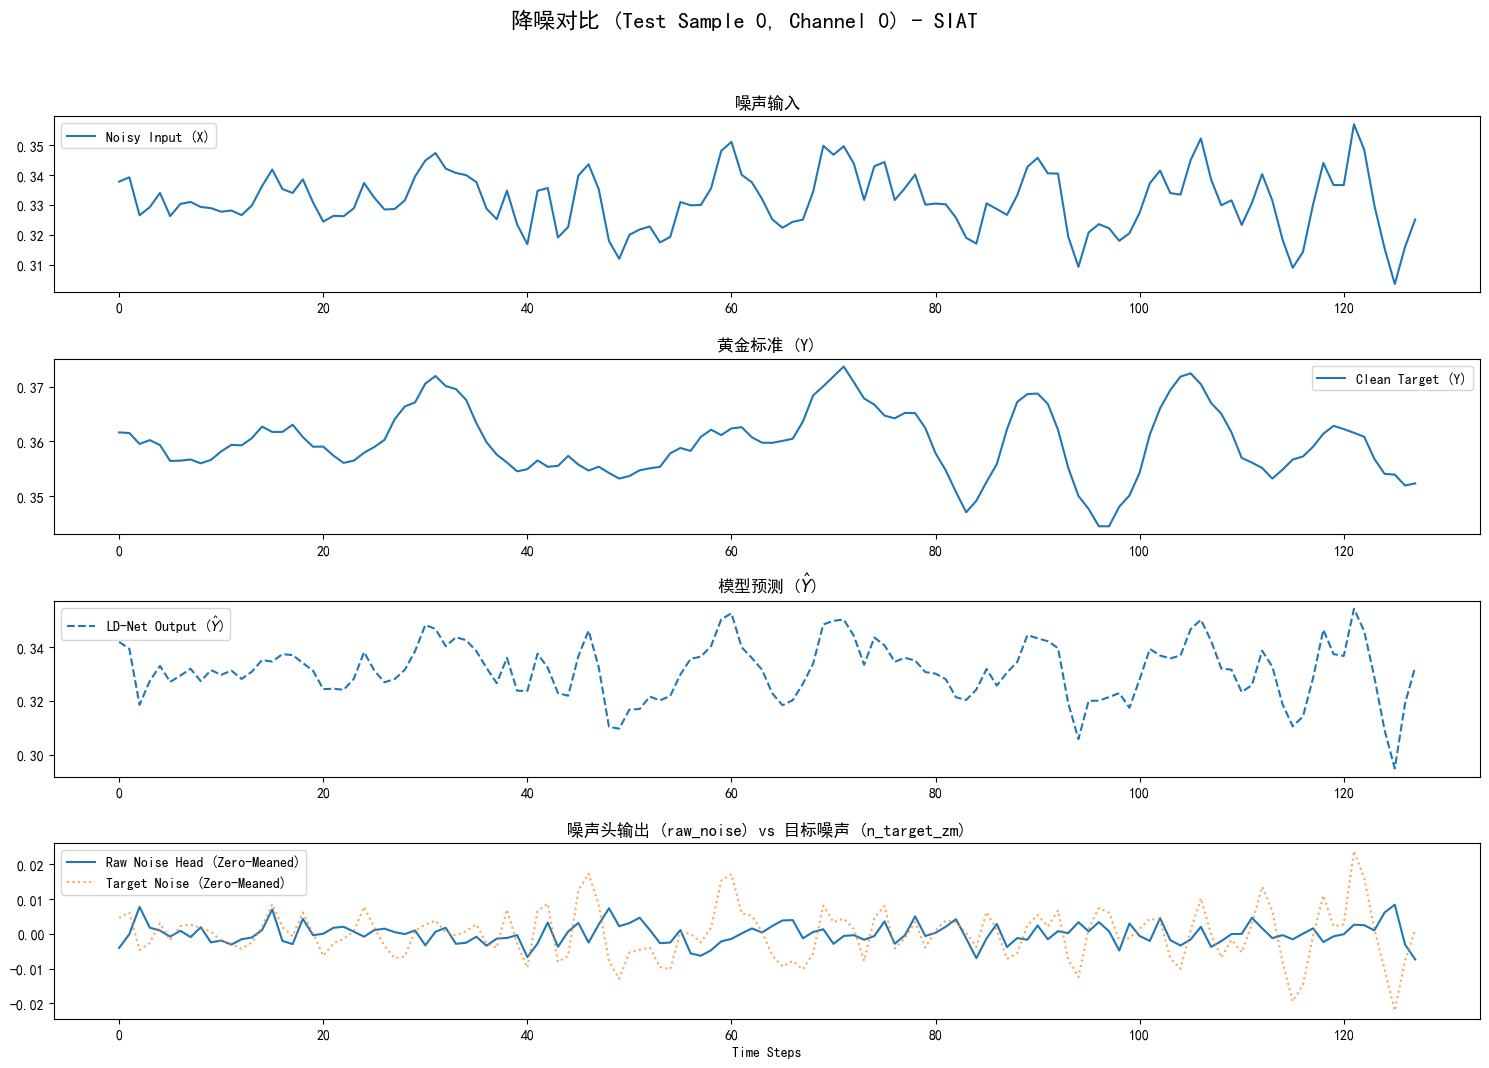

In [7]:
# 单元格 8：可视化降噪结果 (💡 关键修正 E：兼容双输出)
print("--- 可视化样本 ---")

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']  # 中文 + 英文后备
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['mathtext.fontset'] = 'dejavusans'  # 让 $\hat{Y}$ 用西文字体渲染

noisy_X_batch, clean_Y_batch = next(iter(test_loader))
noisy_X_batch = noisy_X_batch.to(DEVICE)
clean_Y_batch = clean_Y_batch.to(DEVICE)

model.eval()
with torch.no_grad():
    # --- 💡 关键改动点 E：兼容双输出 ---
    out = model(noisy_X_batch)
    if isinstance(out, tuple):
        clean_pred_batch, raw_noise_batch = out
    else:
        clean_pred_batch = out
        raw_noise_batch = None
    # --- 修正结束 ---

# 移回 CPU 并转为 numpy
noisy_X = noisy_X_batch.detach().cpu().numpy()
clean_Y = clean_Y_batch.detach().cpu().numpy()
predicted = clean_pred_batch.detach().cpu().numpy()
raw_noise = None if raw_noise_batch is None else raw_noise_batch.detach().cpu().numpy()

# 绘制第一个样本的第一通道
sample_idx, channel_idx = 0, 0
time_axis = np.arange(noisy_X.shape[2])  # (B, C, L)

n_rows = 3 if raw_noise is None else 4
plt.figure(figsize=(15, 2.8 * n_rows))
plt.suptitle(f"降噪对比 (Test Sample {sample_idx}, Channel {channel_idx}) - {DATASET_NAME}", fontsize=16)

plt.subplot(n_rows, 1, 1)
plt.plot(time_axis, noisy_X[sample_idx, channel_idx, :], label='Noisy Input (X)')
plt.legend()
plt.title("噪声输入")

plt.subplot(n_rows, 1, 2)
plt.plot(time_axis, clean_Y[sample_idx, channel_idx, :], label='Clean Target (Y)')
plt.legend()
plt.title("黄金标准 (Y)")

plt.subplot(n_rows, 1, 3)
plt.plot(time_axis, predicted[sample_idx, channel_idx, :],
         linestyle='--', label=r'LD-Net Output ($\hat{Y}$)')
plt.legend()
plt.title(r"模型预测 ($\hat{Y}$)")

# --- 💡 关键改动点 E：可视化 raw_noise ---
if raw_noise is not None:
    plt.subplot(n_rows, 1, 4)
    plt.plot(time_axis, raw_noise[sample_idx, channel_idx, :], label='Raw Noise Head (Zero-Meaned)')
    n_target_zm_np = (noisy_X[sample_idx, channel_idx, :] - clean_Y[sample_idx, channel_idx, :])
    n_target_zm_np = n_target_zm_np - n_target_zm_np.mean()
    plt.plot(time_axis, n_target_zm_np, label='Target Noise (Zero-Meaned)', linestyle=':', alpha=0.7)
    plt.legend()
    plt.title("噪声头输出 (raw_noise) vs 目标噪声 (n_target_zm)")
# --- 修正结束 ---

plt.xlabel("Time Steps")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

try:
    plt.savefig(figure_save_path, dpi=150)
    print(f"✅ 可视化图表已保存到: {figure_save_path}")
except Exception as e:
    print(f"⚠️ 未保存图像（figure_save_path 未定义或路径无效）: {e}")

plt.show()

In [12]:
# 单元格 9：复杂度与速度分析
print("--- ============ 复杂度与速度分析 ============ ---")
model.to(DEVICE).eval()

# 1. 定义一个虚拟输入 (Batch_size=1)
# (C 和 window 应该来自 common_params.py)
dummy_input_cpu = torch.randn(1, C, window).to('cpu')
dummy_input_gpu = dummy_input_cpu.to(DEVICE)

# 2. 计算参数量 (Parameters)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[1] 模型参数量 (Parameters): {total_params / 1e6:.4f} M")

# 3. 计算 MAdds (FLOPs)
madds_val = 0.0
try:
    model_cpu = model.to('cpu')
    madds, _ = profile(model_cpu, inputs=(dummy_input_cpu, ), verbose=False)
    madds_val = madds / 1e6 # MAdds in Million
    print(f"[2] 乘加运算量 (MAdds): {madds_val:.4f} M")
except Exception as e:
    print(f"[2] MAdds 计算失败 (thop可能不支持U-Net的某些操作): {e}")

# 4. 推理时间 (Inference Time) - GPU
avg_time_gpu_ms = 0.0
if DEVICE.type == 'cuda':
    model.to(DEVICE) # 确保模型在 GPU
    repetitions = 300
    starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    timings_gpu = np.zeros((repetitions, 1))

    # 预热
    for _ in range(50): _ = model(dummy_input_gpu)

    with torch.no_grad():
        for rep in range(repetitions):
            starter.record()
            _ = model(dummy_input_gpu)
            ender.record()
            torch.cuda.synchronize()
            timings_gpu[rep] = starter.elapsed_time(ender)

    avg_time_gpu_ms = np.sum(timings_gpu) / repetitions
    print(f"[3] GPU 单窗推理时间 (avg over {repetitions}): {avg_time_gpu_ms:.6f} ms")

# 5. 推理时间 (Inference Time) - CPU
model_cpu = model.to('cpu')
repetitions = 100
timings_cpu = np.zeros((repetitions, 1))
# 预热
for _ in range(10): _ = model_cpu(dummy_input_cpu)

with torch.no_grad():
    for rep in range(repetitions):
        start_time = time.perf_counter()
        _ = model_cpu(dummy_input_cpu)
        end_time = time.perf_counter()
        timings_cpu[rep] = (end_time - start_time) * 1000

avg_time_cpu_ms = np.sum(timings_cpu) / repetitions
print(f"[4] CPU 单窗推理时间 (avg over {repetitions}): {avg_time_cpu_ms:.6f} ms")
print("--- ============================================== ---")

# --- 加载、更新并保存复杂度指标到 JSON ---
if os.path.exists(results_json_path):
    with open(results_json_path, 'r') as f:
        results_data = json.load(f)
else:
    results_data = {}

complexity_data = {
    "params_M": total_params / 1e6,
    "madds_M": madds_val,
    "inference_time_gpu_ms": avg_time_gpu_ms,
    "inference_time_cpu_ms": avg_time_cpu_ms
}
# 将复杂度指标合并到 "ld_net_metrics" 字典中
if "ld_net_metrics" not in results_data:
    results_data["ld_net_metrics"] = {}
results_data["ld_net_metrics"].update(complexity_data)

# 将超参数也保存下来
results_data["hyperparameters"] = {
    "lr": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "weight_decay": WEIGHT_DECAY,
    "early_stop_patience": PATIENCE
}

with open(results_json_path, 'w') as f:
    json.dump(results_data, f, indent=4)

print(f"\n✅ 复杂度指标已更新到: {results_json_path}")
printlog(f"--- {DATASET_NAME} 评估全部完成! ---", line_break=True)

--- ============ 复杂度与速度分析 ============ ---
[1] 模型参数量 (Parameters): 1.5131 M
[2] 乘加运算量 (MAdds): 46.8664 M
[3] GPU 单窗推理时间 (avg over 300): 2.206569 ms
[4] CPU 单窗推理时间 (avg over 100): 3.096348 ms
--- ============================================== ---

✅ 复杂度指标已更新到: E:\基于肌电图的下肢运动模式识别\Code2\trainTest\LD_train Test\checkpoints\LD_Net_SIAT\test_results.json

============================================================2025-11-13 18:01:13
--- SIAT 评估全部完成! ---...



🔍 正在扫描测试集，寻找适合展示的高噪声样本...
✅ 优化版图表已生成: Figure_3.1_Optimized.png


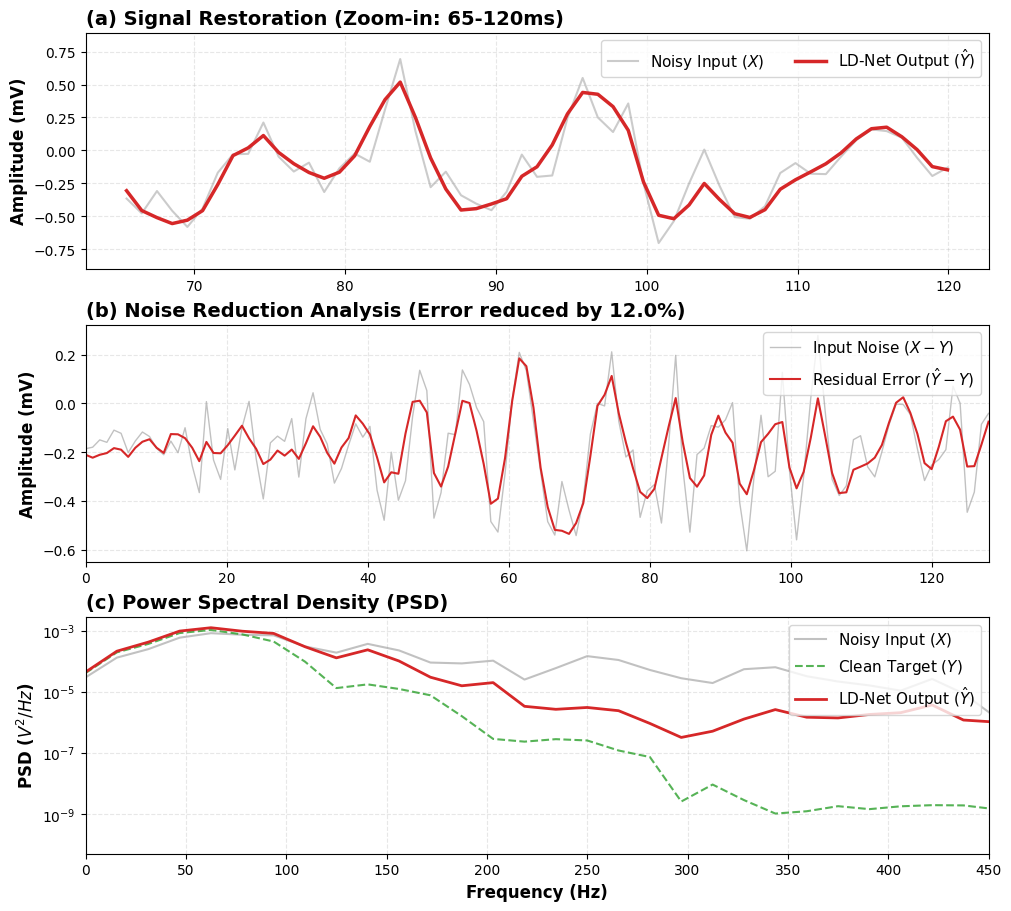

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ==========================================
# 0. 变量名与环境检查
# ==========================================
# 继承之前的模型变量
if 'model_inference' in globals():
    model = model_inference
elif 'model' in globals():
    pass
else:
    raise NameError("❌ 找不到模型变量！请先运行之前的【智能加载模型】代码。")

if 'DEVICE' not in globals():
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# 1. 寻找最佳样本 (保持逻辑不变)
# ==========================================
print("🔍 正在扫描测试集，寻找适合展示的高噪声样本...")

best_sample = None
max_noise_energy = -1
scan_limit_batches = 15 # 稍微多扫一点，确保找到动作活跃的片段

model.eval()

with torch.no_grad():
    for batch_idx, (inputs, targets) in enumerate(test_loader):
        if batch_idx >= scan_limit_batches:
            break

        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        noise_energy_map = torch.mean((inputs - targets)**2, dim=2)
        b_max_val, b_indices = torch.max(noise_energy_map, dim=0)
        best_ch_val, best_ch_idx = torch.max(b_max_val, dim=0)

        current_max_noise = best_ch_val.item()

        if current_max_noise > max_noise_energy:
            max_noise_energy = current_max_noise
            best_b_idx = b_indices[best_ch_idx].item()
            c_idx = best_ch_idx.item()

            output = model(inputs)
            if isinstance(output, tuple):
                clean_pred, _ = output
            else:
                clean_pred = output

            best_sample = {
                'x': inputs[best_b_idx, c_idx].cpu().numpy(),
                'y': targets[best_b_idx, c_idx].cpu().numpy(),
                'y_hat': clean_pred[best_b_idx, c_idx].cpu().numpy()
            }

if best_sample is None:
    inputs, targets = next(iter(test_loader))
    best_sample = {
        'x': inputs[0, 0].numpy(), 'y': targets[0, 0].numpy(), 'y_hat': inputs[0, 0].numpy()
    }

# ==========================================
# 2. 绘制 SCI 图 (按要求优化)
# ==========================================
x = best_sample['x']
y = best_sample['y']
y_hat = best_sample['y_hat']

# 残差计算 (b图保留对比)
residual_in = x - y
residual_out = y_hat - y

fs = 1000
time_axis = np.linspace(0, len(x)/fs, len(x)) * 1000 # ms

# --- 关键修改：锁定 65-120ms ---
zoom_start = 65
zoom_end = 120
zoom_mask = (time_axis >= zoom_start) & (time_axis <= zoom_end)

# 创建画布
fig = plt.figure(figsize=(10, 9), constrained_layout=True)
gs = fig.add_gridspec(3, 2)

# =========================================================================
# (a) Time Domain: Noisy Input vs Output (Y线已隐藏)
# =========================================================================
ax1 = fig.add_subplot(gs[0, :])

# 1. Noisy Input (Gray)
ax1.plot(time_axis[zoom_mask], x[zoom_mask],
         color='#999999', alpha=0.5, linewidth=1.5,
         label='Noisy Input ($X$)')

# 2. LD-Net Output (Red) - 重点突出
ax1.plot(time_axis[zoom_mask], y_hat[zoom_mask],
         color='#d62728', linewidth=2.5,  # <--- 线宽加粗，强调拟合
         label='LD-Net Output ($\hat{Y}$)')

# --- 优化显示：确保尖峰不被遮挡 ---
# 自动调整 Y 轴范围，留出一点头部空间
y_min_zoom = np.min(x[zoom_mask])
y_max_zoom = np.max(x[zoom_mask])
ax1.set_ylim(y_min_zoom - 0.2, y_max_zoom + 0.2)

# --- 标题与标签设置 ---
ax1.set_title(f'(a) Signal Restoration (Zoom-in: {zoom_start}-{zoom_end}ms)',
              fontweight='bold', loc='left',
              fontsize=14) # ⬅️【在这里修改标题字号】
ax1.set_ylabel('Amplitude (mV)',
               fontsize=12, fontweight='bold') # ⬅️【在这里修改Y轴标签字号】

# --- 图例设置 ---
ax1.legend(loc='upper right', ncol=2, frameon=True,
           fontsize=11) # ⬅️【在这里修改图例字号】
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.tick_params(axis='both', which='major', labelsize=10) # ⬅️【在这里修改刻度数字字号】


# =========================================================================
# (b) Noise Reduction Analysis (保留)
# =========================================================================
ax2 = fig.add_subplot(gs[1, :])
ax2.plot(time_axis, residual_in, color='#999999', alpha=0.6, linewidth=1,
         label='Input Noise ($X - Y$)')
ax2.plot(time_axis, residual_out, color='#d62728', linewidth=1.5,
         label='Residual Error ($\hat{Y} - Y$)')

# 计算改善比例
rmse_in = np.sqrt(np.mean(residual_in**2))
rmse_out = np.sqrt(np.mean(residual_out**2))
reduction_ratio = (1 - rmse_out/rmse_in) * 100

ax2.set_title(f'(b) Noise Reduction Analysis (Error reduced by {reduction_ratio:.1f}%)',
              fontweight='bold', loc='left',
              fontsize=14) # ⬅️【在这里修改标题字号】
ax2.set_ylabel('Amplitude (mV)',
               fontsize=12, fontweight='bold') # ⬅️【在这里修改Y轴标签字号】
ax2.set_xlim(0, 128)

ax2.legend(loc='upper right', frameon=True,
           fontsize=11) # ⬅️【在这里修改图例字号】
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.tick_params(axis='both', which='major', labelsize=10) # ⬅️【在这里修改刻度数字字号】


# =========================================================================
# (c) PSD Comparison (0-450Hz)
# =========================================================================
ax3 = fig.add_subplot(gs[2, :])
f_x, p_x = welch(x, fs, nperseg=64)
f_y, p_y = welch(y, fs, nperseg=64)
f_hat, p_hat = welch(y_hat, fs, nperseg=64)

ax3.semilogy(f_x, p_x, color='#999999', alpha=0.6, label='Noisy Input ($X$)')
ax3.semilogy(f_y, p_y, color='#2ca02c', linestyle='--', alpha=0.8, label='Clean Target ($Y$)')
ax3.semilogy(f_hat, p_hat, color='#d62728', linewidth=2, label='LD-Net Output ($\hat{Y}$)')

ax3.set_title('(c) Power Spectral Density (PSD)',
              fontweight='bold', loc='left',
              fontsize=14) # ⬅️【在这里修改标题字号】
ax3.set_xlabel('Frequency (Hz)',
               fontsize=12, fontweight='bold') # ⬅️【在这里修改X轴标签字号】
ax3.set_ylabel('PSD ($V^2/Hz$)',
               fontsize=12, fontweight='bold') # ⬅️【在这里修改Y轴标签字号】

# --- 关键修改：截断到 450Hz ---
ax3.set_xlim(0, 450)

ax3.legend(loc='upper right', frameon=True,
           fontsize=11) # ⬅️【在这里修改图例字号】
ax3.grid(True, linestyle='--', alpha=0.3)
ax3.tick_params(axis='both', which='major', labelsize=10) # ⬅️【在这里修改刻度数字字号】


# 保存并显示
save_path = "Figure_3.1_Optimized.png"
plt.savefig(save_path, dpi=300)
print(f"✅ 优化版图表已生成: {save_path}")
plt.show()

In [11]:
import pandas as pd
import os

# ==========================================
# 导出图表原始数据
# ==========================================

# 1. 检查数据是否存在
if 'best_sample' not in globals():
    print("❌ 内存中找不到 best_sample！请先运行上面画图的那个单元格。")
else:
    # 提取数据
    raw_x = best_sample['x']      # Noisy Input
    clean_y = best_sample['y']    # Clean Target
    pred_y_hat = best_sample['y_hat'] # LD-Net Output

    # 2. 打印基本统计信息
    print(f"--- 数据来源统计 ---")
    print(f"数据长度: {len(raw_x)} 点 (对应 {len(raw_x)/1000} 秒)")
    print(f"最大值: {raw_x.max():.4f} mV")
    print(f"最小值: {raw_x.min():.4f} mV")

    # 3. 保存为 CSV (Excel 可打开)
    # 创建一个 DataFrame
    df = pd.DataFrame({
        'Time_ms': np.linspace(0, len(raw_x)-1, len(raw_x)), # 0, 1, 2... ms
        'Noisy_Input_X': raw_x,
        'Clean_Target_Y': clean_y,
        'LDNet_Output_Y_hat': pred_y_hat,
        'Input_Noise_Residual': raw_x - clean_y,
        'Output_Error_Residual': pred_y_hat - clean_y
    })

    # 保存路径
    save_csv_path = "Figure_3.1_RawData.csv"
    df.to_csv(save_csv_path, index=False, float_format='%.6f')

    print(f"\n✅ 原始数据已保存为 Excel 表格: {save_csv_path}")
    print(f"您可以直接用 Excel 打开它，查看具体的波形数值。")

--- 数据来源统计 ---
数据长度: 128 点 (对应 0.128 秒)
最大值: 0.6931 mV
最小值: -0.7020 mV

✅ 原始数据已保存为 Excel 表格: Figure_3.1_RawData.csv
您可以直接用 Excel 打开它，查看具体的波形数值。


In [6]:
#频域数据
import numpy as np
import pandas as pd
import torch
import os
from scipy.signal import welch

# ==========================================
# 1. 配置路径
# ==========================================
# 输出文件的保存目录
save_dir = r"E:\研究生\11.小论文\图表、数据\T检验、波形图数据"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"创建目录: {save_dir}")

# 输出文件名
save_path = os.path.join(save_dir, "频域图数据.csv")

# 你的测试集 npz 路径 (请确认此路径是否正确)
test_data_path = r"E:\基于肌电图的下肢运动模式识别\Code2\preProcessing\SIAT_LLMD_trainData\Denoising_TrainSet_XY\Sub35_XY_TrainData.npz"

# ==========================================
# 2. 准备数据与模型
# ==========================================
# 检查变量是否已存在 (如果在 Notebook 里跑过前面的代码)
if 'model' not in globals() or 'test_loader' not in globals():
    print("⚠️ 正在初始化数据加载器和模型 (如果已加载过会跳过)...")
    # --- 加载数据 ---
    data = np.load(test_data_path)
    x_test = data['x_data'] # [N, C, 128] 或 [N, 128, C]
    y_test = data['y_data']

    # 维度修正
    if x_test.shape[-1] != 128:
        x_test = x_test.transpose(0, 2, 1)
        y_test = y_test.transpose(0, 2, 1)

    # 转 Tensor
    inputs = torch.FloatTensor(x_test)
    targets = torch.FloatTensor(y_test)

    from torch.utils.data import DataLoader, TensorDataset
    dataset = TensorDataset(inputs, targets)
    test_loader = DataLoader(dataset, batch_size=32, shuffle=True)

    # --- 加载模型 ---
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    # 请确保路径对
    model_path = "checkpoints/LD_Net_SIAT/best_model.pth"
    model = torch.load(model_path, map_location=DEVICE)
    model.to(DEVICE)
    model.eval()
else:
    print("✅ 检测到内存中已存在 model 和 test_loader，直接使用。")

# ==========================================
# 3. 批量提取 200 个窗口的数据
# ==========================================
N_WINDOWS = 200  # 抽取的窗口数量
rows = []
count = 0

print(f"🚀 开始提取 {N_WINDOWS} 个窗口的数据...")

with torch.no_grad():
    for batch_idx, (bx, by) in enumerate(test_loader):
        if count >= N_WINDOWS: break

        bx, by = bx.to(DEVICE), by.to(DEVICE)

        # 推理
        out = model(bx)
        if isinstance(out, tuple): b_hat = out[0]
        else: b_hat = out

        # 转 Numpy
        bx_np = bx.cpu().numpy()
        by_np = by.cpu().numpy()
        b_hat_np = b_hat.cpu().numpy()

        # 遍历 Batch
        for i in range(bx_np.shape[0]):
            if count >= N_WINDOWS: break

            # 策略：选能量最大的通道
            ch = np.argmax(np.std(by_np[i], axis=1))

            # 获取 128 点数据
            sig_x = bx_np[i, ch, :]
            sig_y = by_np[i, ch, :]
            sig_hat = b_hat_np[i, ch, :]

            # 存入列表 (长格式：每行是一个时间点，方便查阅)
            # 或者 宽格式：每行是一个窗口 (更适合 CSV 阅读)
            # 这里采用宽格式：一行代表一个窗口的128个点
            # 但为了方便画 PSD，我们存成"每个窗口一行"太宽了，不如存成"列表"

            # 为了表格可读性，我们保存 200行，每行 3列数据(字符串形式)或者 3*128 列
            # 最好的方式：保存 Flatten 后的数据，或者加 Window_ID

            for t in range(128):
                rows.append({
                    'Window_ID': count,
                    'Time_Step': t,
                    'Noisy_Input': sig_x[t],
                    'Clean_Target': sig_y[t],
                    'LDNet_Output': sig_hat[t]
                })

            count += 1

# ==========================================
# 4. 保存为 CSV
# ==========================================
df = pd.DataFrame(rows)
df.to_csv(save_path, index=False)

print(f"✅ 数据已保存！")
print(f"📂 文件路径: {save_path}")
print(f"📊 表格大小: {df.shape} (200窗口 * 128点 = 25600行)")
print(f"👀 你现在可以去文件夹里打开 Excel 看看数据了！")

✅ 检测到内存中已存在 model 和 test_loader，直接使用。
🚀 开始提取 200 个窗口的数据...
✅ 数据已保存！
📂 文件路径: E:\研究生\11.小论文\图表、数据\T检验、波形图数据\频域图数据.csv
📊 表格大小: (25600, 5) (200窗口 * 128点 = 25600行)
👀 你现在可以去文件夹里打开 Excel 看看数据了！
